## EDA - Análisis Exploratorio

Tu EDA debería tener:

- Data overview - check
- Missing analysis - check
- Univariate distributions - check
- Outliers - check
- Target relationship - check
- Categorical analysis - check
- Correlation analysis - check
- Temporal stability - check
- Leakage detection - check
- Business sanity checks

Covers:

- Shape, dtypes, missing values
- Target distribution and class imbalance
- Temporal distribution of records and default rate per period
- Numeric feature distributions (histograms + box plots)
- Correlation heatmap
- Train / Test / Monitor split sizes

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

sns.set_theme(style= 'whitegrid', palette = 'muted')

#### Data Overview
- shape
- tipos de variables
- cardinalidad
- IDs (identificar si hay feature ID)
- duplicados (duplicado exacto de fila o duplicado de entiendad como 'customer_id' aparece varias veces puede ser correcto o incorrecto)
- constantes (detectar features constantes, es decir que tienen un solo valor, no aportan variación)
- missing %
- MCAR / MAR / MNAR
- sanity checks negocio (aunque el dato exista, tiene sentido? como ejm: edad negativa o igual a 150, income = 0)

In [2]:
with open("../params.yaml") as f:
    parameters = yaml.safe_load(f)

DATA = parameters["data"]
FEATURES = parameters["features"]
MODEL = parameters["model"]

NUMERIC = FEATURES["numeric"]
CATEGORICAL = FEATURES["categorical"]
TARGET = FEATURES["target"]

In [1]:
class EDA:
    def __init__(self):
        pass

In [4]:
df_train = pd.read_csv(f"{DATA['train_data']}")
df_train.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [5]:
df_test = pd.read_csv(f'{DATA["test_data"]}')
df_test

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months
0,CST_142525,Siva,52,F,Y,N,0.0,232640.53,998.0,Unknown,2.0,0.0,14406.73,26524.40,4,779.0,0,0
1,CST_129215,Scott,48,F,N,N,1.0,284396.79,1338.0,Unknown,3.0,0.0,57479.99,68998.72,70,806.0,0,0
2,CST_138443,Victoria,50,F,N,N,1.0,149419.28,1210.0,Unknown,3.0,0.0,21611.01,25187.80,71,528.0,2,0
3,CST_123812,John McCrank,30,F,N,N,1.0,160437.54,503.0,Laborers,2.0,1.0,28990.76,29179.39,9,815.0,0,0
4,CST_144450,Martinne,52,M,N,Y,0.0,233480.37,157.0,Laborers,2.0,1.0,54213.72,82331.82,82,613.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11378,CST_142412,Solarina,53,F,N,N,0.0,266824.38,3051.0,Sales staff,1.0,0.0,17791.56,64483.93,74,823.0,0,0
11379,CST_107967,Jonathan Cable,33,F,NaN,N,0.0,124310.85,365248.0,Unknown,1.0,0.0,26576.79,29851.73,60,712.0,0,0
11380,CST_134002,Robin,27,M,Y,Y,1.0,364652.81,3431.0,Laborers,3.0,0.0,28658.55,69336.96,67,674.0,0,0
11381,CST_146856,Lauren,36,F,N,Y,0.0,128769.02,16320.0,Medicine staff,1.0,0.0,11527.38,26908.03,17,684.0,0,0


In [91]:
## shape, dtype, cardinalidad (unicos), duplicates, % missings

## Numeric
shape_rows = df_train.shape[0]
duplicates = df_train.duplicated().sum()
dtype_num = [d for d in df_train[NUMERIC].dtypes.astype("str").tolist()]
cardinalidad_num = [len(df_train[d].unique()) for d in NUMERIC]
missings_num = [round(((df_train[d].isnull().sum()/shape_rows)*100), 2) for d in NUMERIC]

dtype_cat = [d for d in df_train[CATEGORICAL].dtypes.astype("str").tolist()]
cardinalidad_cat = [len(df_train[d].unique()) for d in CATEGORICAL]
missings_cat = [round(((df_train[d].isnull().sum()/shape_rows)*100), 2) for d in CATEGORICAL]


data_overview_num = pd.DataFrame({
    "Tipo Variable": dtype_num,
    "Valores Únicos": cardinalidad_num,
    "%Missings": missings_num
}, index= NUMERIC).sort_values(by="%Missings", ascending = False)

data_overview_cat = pd.DataFrame({
    "Tipo Variable": dtype_cat,
    "Valores Únicos": cardinalidad_cat,
    "%Missings": missings_cat
}, index= CATEGORICAL).sort_values(by="%Missings", ascending = False)



print("=== Vista General ===")
print(f'Tamaño del dataset       : {shape_rows} filas')
print(f'Cantidad de duplicados   : {duplicates} duplicados')
print('')
print("=== Features Numéricas ===")
display(data_overview_num)
print('=== Features Categóricas ===')
display(data_overview_cat)
print(f'''Features Numéricas con Missings:
- no_of_children (1.7%)
- no_of_days_employed (1.02%)
- yearly_debt_payments (0.21%)
- migrant_worker (0.19%)
- total_family_members (0.18%)
- credit_score (0.02%)

Features Categóricas:
- owns_car (1.2%)''')

=== Vista General ===
Tamaño del dataset       : 45528 filas
Cantidad de duplicados   : 0 duplicados

=== Features Numéricas ===


,Tipo Variable,Valores Únicos,%Missings
no_of_children,float64,11,1.70
no_of_days_employed,float64,7875,1.02
yearly_debt_payments,float64,45252,0.21
migrant_worker,float64,3,0.19
total_family_members,float64,11,0.18
credit_score,float64,451,0.02
age,int64,33,0.00
net_yearly_income,float64,45502,0.00
credit_limit,float64,45371,0.00
credit_limit_used(%),int64,100,0.00


=== Features Categóricas ===


,Tipo Variable,Valores Únicos,%Missings
owns_car,object,3,1.2
gender,object,3,0.0
owns_house,object,2,0.0
occupation_type,object,19,0.0


Features Numéricas con Missings:
- no_of_children (1.7%)
- no_of_days_employed (1.02%)
- yearly_debt_payments (0.21%)
- migrant_worker (0.19%)
- total_family_members (0.18%)
- credit_score (0.02%)

Features Categóricas:
- owns_car (1.2%)


#### Distribución del Target y balanceamiento

In [7]:
df_train[TARGET].value_counts(normalize = True)

default_in_last_6months
0    0.94946
1    0.05054
Name: proportion, dtype: float64

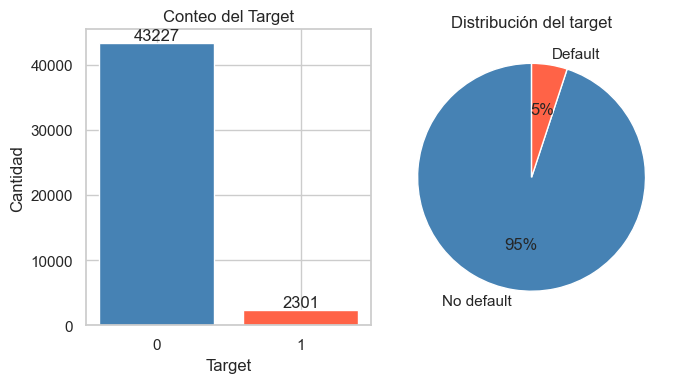

=== Reporte de Balanceamiento del Target ===
A nivel del dataset train tiene:
- 5% -> Default
- 95% -> No Default


In [93]:
fig, ax = plt.subplots(nrows= 1, ncols= 2, figsize = (7, 4))

bars = ax[0].bar(
    x = [0, 1],
    height= df_train[TARGET].value_counts(),
    color = ["steelblue", "tomato"]
)

ax[0].bar_label(bars, fmt = "%d")
ax[0].set(title = 'Conteo del Target', ylabel = 'Cantidad', xlabel = 'Target')
ax[0].set_xticks([0, 1])

ax[1].pie(
    x = df_train[TARGET].value_counts(),
    labels = ["No default", "Default"],
    colors = ["steelblue", "tomato"],
    autopct = "%.0f%%",
    startangle = 90
)
ax[1].set_title("Distribución del target")

plt.tight_layout()
plt.show()
print(f'=== Reporte de Balanceamiento del Target ===')
print(f'''A nivel del dataset train tiene:
- 5% -> Default
- 95% -> No Default''')


In [10]:
agg_target_vs_numeric = df_train.groupby(TARGET)[NUMERIC].mean()
agg_target_vs_numeric = agg_target_vs_numeric.reset_index(drop= True, level= 0)
agg_target_vs_numeric

,age,no_of_children,net_yearly_income,no_of_days_employed,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults
0,38.996507,0.417043,198325.991639,68712.544105,2.155260,0.176460,31843.259278,43007.473191,50.515627,793.252869,0.011174
1,38.935246,0.488506,244420.482047,46915.885577,2.211053,0.228895,30927.199255,53710.665493,84.535854,586.203913,0.991308


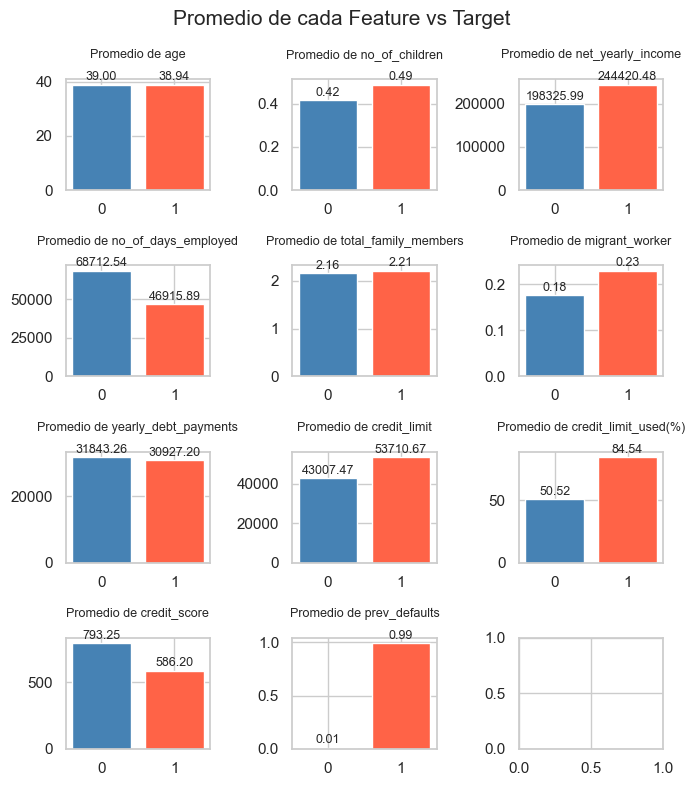

In [13]:
n_cols = 3
n_rows = ((len(NUMERIC) -1 ) // 3) + 1

fig, ax = plt.subplots(ncols= n_cols, nrows= n_rows, figsize= (7, 2 * n_rows))

axes = ax.flatten()

for i, ax, feat in list(zip(range(len(NUMERIC)), axes, NUMERIC)):
    bars = axes[i].bar(
    x = [0, 1],
    height = agg_target_vs_numeric[feat],
    color = ['steelblue', 'tomato']
    )
    axes[i].bar_label(bars, fmt = '%.2f', fontsize = 9, padding= 1)
    axes[i].set_xticks([0, 1])
    #axes[i].set_xlabel('Target', fontsize = 9)
    axes[i].set_title(f'Promedio de {feat}', fontsize = 9, pad = 15)

# axes[0].bar(
#     x = [0, 1],
#     height = agg_target_vs_numeric["age"],
#     color = ['steelblue', 'tomato']
# )
# axes[0].set_xticks([0, 1])
plt.suptitle("Promedio de cada Feature vs Target", fontsize= 15)
plt.tight_layout()
plt.show()

In [14]:
print(f"=== Resultado ===")
print(f'Se observa señal algunas señales fuertes que presuntamente indicarían poder predictivo relevante ')
print(f'''Algunas de ellas son:
- prev_defaults
- credit_score
- credit_limit_used(%)
- credit_limit
- no_of_days_employed
- net_yearly_income''')

=== Resultado ===
Se observa señal algunas señales fuertes que presuntamente indicarían poder predictivo relevante 
Algunas de ellas son:
- prev_defaults
- credit_score
- credit_limit_used(%)
- credit_limit
- no_of_days_employed
- net_yearly_income


#### Distribución de las features numéricas

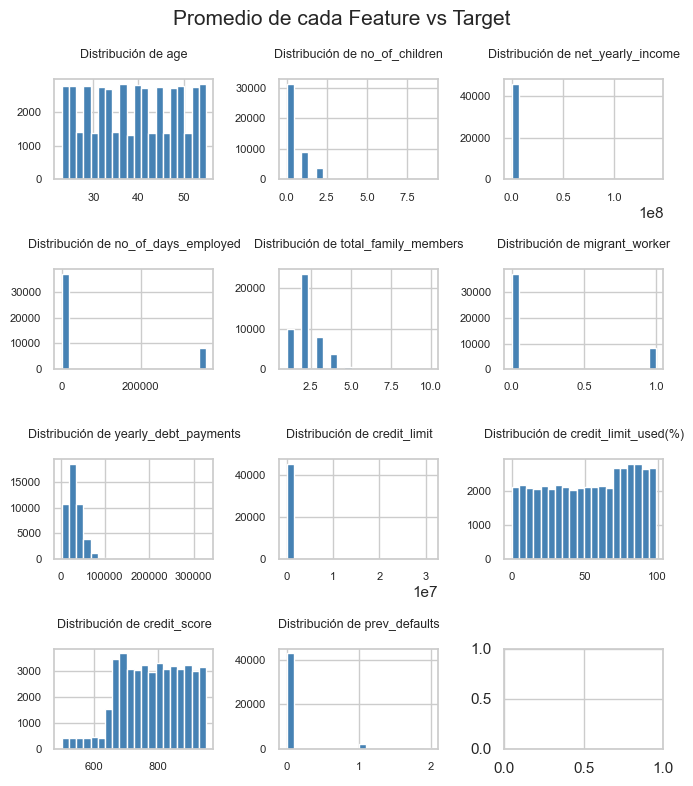

=== Reporte de Distribución de Features ===
Se observa que hay muchas features con sesgo hacia la derecha por naturaleza de la variable, 
por ello se recomienda aplicar una log-tranformation o el método WOE en al menos las siguientes:
- no_of_children
- net_yearly_income
- no_of_days_employed
- credit_limit
- yearly_debt_payments


In [ ]:
n_cols = 3
n_rows = ((len(NUMERIC) -1 ) // 3) + 1

fig, ax = plt.subplots(ncols= n_cols, nrows= n_rows, figsize= (7, 2 * n_rows))

axes = ax.flatten()

for i, ax, feat in list(zip(range(len(NUMERIC)), axes, NUMERIC)):
    hist = axes[i].hist(
    x = df_train[feat],
    bins = 20,
    color = 'steelblue'
    )
    axes[i].set_title(f'Distribución de {feat}', fontsize = 9, pad = 15)
    axes[i].tick_params(axis = 'both', labelsize = 8)

plt.suptitle("Distribución de Features Numéricas", fontsize= 15)
plt.tight_layout()
plt.show()

print(f'=== Reporte de Distribución de Features ===')
print(f'''Se observa que hay muchas features con sesgo hacia la derecha por naturaleza de la variable, 
por ello se recomienda aplicar una log-tranformation o el método WOE en al menos las siguientes:
- no_of_children
- net_yearly_income
- no_of_days_employed
- no_of_days_employed
- credit_limit
- yearly_debt_payments''')

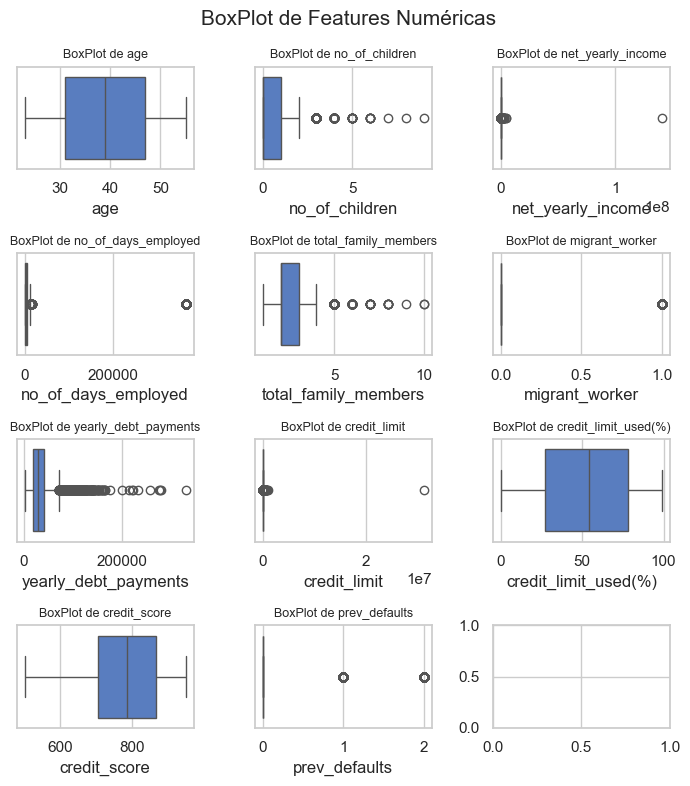

=== Reporte de BoxPlot ===
Se observa que hay muchas features con outliers (fuera del rango intercuartílico superior), 
por ello se recomienda aplicar una log-tranformation o el método WOE en al menos las siguientes:
- no_of_children
- net_yearly_income
- no_of_days_employed
- no_of_days_employed
- credit_limit
- yearly_debt_payments


In [76]:
n_cols = 3
n_rows = ((len(NUMERIC) -1 ) // 3) + 1

fig, ax = plt.subplots(ncols= n_cols, nrows= n_rows, figsize= (7, 2 * n_rows))

axes = ax.flatten()

for i, feat in enumerate(NUMERIC):
    sns.boxplot(
        data = df_train,
        x = feat,
        ax = axes[i]
    )
    axes[i].set_title(f'BoxPlot de {feat}', fontsize = 9)

plt.suptitle("BoxPlot de Features Numéricas", fontsize= 15)
plt.tight_layout()
plt.show()

print(f'=== Reporte de BoxPlot ===')
print(f'''Se observa que hay muchas features con outliers (fuera del rango intercuartílico superior), 
por ello se recomienda aplicar una log-tranformation o el método WOE en al menos las siguientes:
- no_of_children
- net_yearly_income
- no_of_days_employed
- no_of_days_employed
- credit_limit
- yearly_debt_payments''')

### Distribución de features categóricas

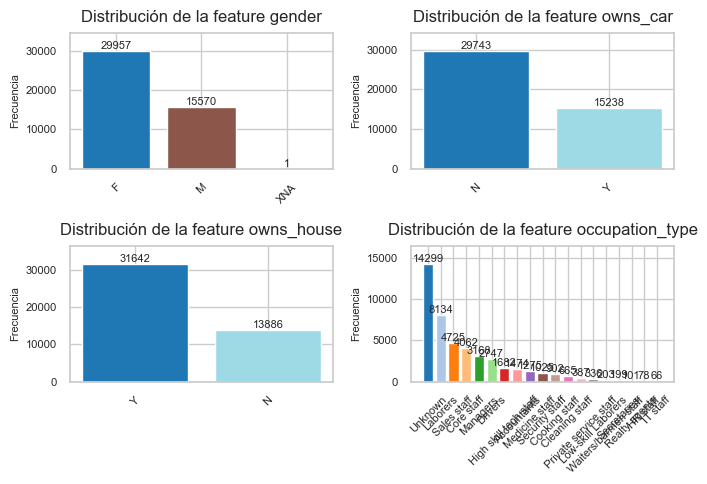

In [20]:
n_cols = 2
n_rows = ((len(CATEGORICAL) - 1) // n_cols) + 1
fig, ax = plt.subplots(ncols= n_cols, nrows= n_rows, figsize = (7, 2.5 * n_rows))
axes = ax.flatten()
#for i, feat in list(zip(range(len(CATEGORICAL)), CATEGORICAL)):
for i, feat in enumerate(CATEGORICAL):
    colors = plt.cm.tab20(np.linspace(0, 1, len(df_train[feat].value_counts().index)))
    bars = axes[i].bar(
        x = df_train[feat].value_counts().index,
        height = df_train[feat].value_counts(),
        color = colors
    )
    max_height = df_train[feat].value_counts().max()
    axes[i].bar_label(bars, fmt = '%.0f', fontsize = 8)
    axes[i].set_title(f'Distribución de la feature {feat}', pad = 8)
    axes[i].tick_params(axis = 'x', labelrotation = 45, labelsize = 8)
    axes[i].tick_params(axis = 'y', labelsize = 8)
    axes[i].set_ylim(0, max_height * 1.15)
    axes[i].set_ylabel("Frecuencia", fontsize = 8)
plt.tight_layout()
plt.show()

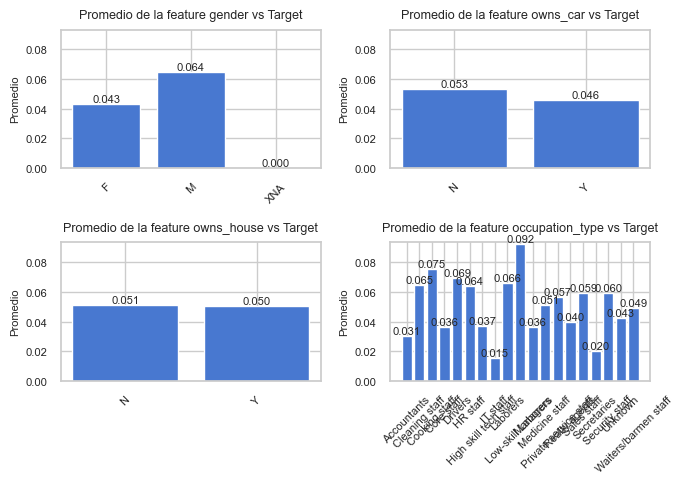

=== Reporte de Análisis Categóricas ===
Se observa que en la feature "gender", hay más hombres con default que mujeres en promedio.
Para las demas features, las categorías están ligeramente equilibradas


In [22]:
n_cols = 2
n_rows = ((len(CATEGORICAL) - 1) // n_cols) + 1
fig, ax = plt.subplots(ncols= n_cols, nrows= n_rows, figsize = (7, 2.5 * n_rows))
axes = ax.flatten()
#for i, feat in list(zip(range(len(CATEGORICAL)), CATEGORICAL)):
for i, feat in enumerate(CATEGORICAL):
    colors = plt.cm.tab20(np.linspace(0, 1, len(df_train[feat].value_counts().index)))
    bars = axes[i].bar(
        x = df_train.groupby(feat).agg({TARGET: 'mean'}).index,
        height = df_train.groupby(feat).agg({TARGET: 'mean'})[TARGET],
        #color = colors
    )
    max_height = df_train.groupby('gender').agg({TARGET: 'mean'})[TARGET].max()
    axes[i].bar_label(bars, fontsize = 8, fmt = '%.3f')
    axes[i].set_title(f'Promedio de la feature {feat} vs Target', pad = 8, fontsize = 9)
    axes[i].tick_params(axis = 'x', labelrotation = 45, labelsize = 8)
    axes[i].tick_params(axis = 'y', labelsize = 8)
    axes[i].set_ylim(top = max_height * 1.45)
    axes[i].set_ylabel("Promedio", fontsize = 8)
plt.tight_layout()
plt.show()

print(f'=== Reporte de Análisis Categóricas ===')
print(f'Se observa que en la feature "gender", hay más hombres con default que mujeres en promedio.')
print(f'Para las demas features, las categorías están ligeramente equilibradas')

#### Análisis de correlación

In [23]:
df_train[NUMERIC].corr(method= 'pearson')

,age,no_of_children,net_yearly_income,no_of_days_employed,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults
age,1.000000,-0.009082,0.004079,0.000506,-0.010640,-0.005519,-0.002453,0.004473,-0.005529,0.000817,0.001393
no_of_children,-0.009082,1.000000,0.008939,-0.243088,0.880278,0.070673,0.028706,0.009354,0.007487,-0.014673,0.019528
net_yearly_income,0.004079,0.008939,1.000000,-0.029367,0.010432,0.001478,0.076958,0.993378,0.002696,-0.009688,-0.004696
no_of_days_employed,0.000506,-0.243088,-0.029367,1.000000,-0.229344,-0.219521,-0.104545,-0.027745,-0.018720,0.035533,-0.036232
total_family_members,-0.010640,0.880278,0.010432,-0.229344,1.000000,0.080634,0.078669,0.010251,0.001928,-0.011524,0.010608
migrant_worker,-0.005519,0.070673,0.001478,-0.219521,0.080634,1.000000,0.014170,-0.000110,0.010198,-0.013319,0.029202
yearly_debt_payments,-0.002453,0.028706,0.076958,-0.104545,0.078669,0.014170,1.000000,0.075169,-0.006850,0.005756,-0.012738
credit_limit,0.004473,0.009354,0.993378,-0.027745,0.010251,-0.000110,0.075169,1.000000,0.003109,-0.009685,-0.004302
credit_limit_used(%),-0.005529,0.007487,0.002696,-0.018720,0.001928,0.010198,-0.006850,0.003109,1.000000,-0.174420,0.252505
credit_score,0.000817,-0.014673,-0.009688,0.035533,-0.011524,-0.013319,0.005756,-0.009685,-0.174420,1.000000,-0.471421


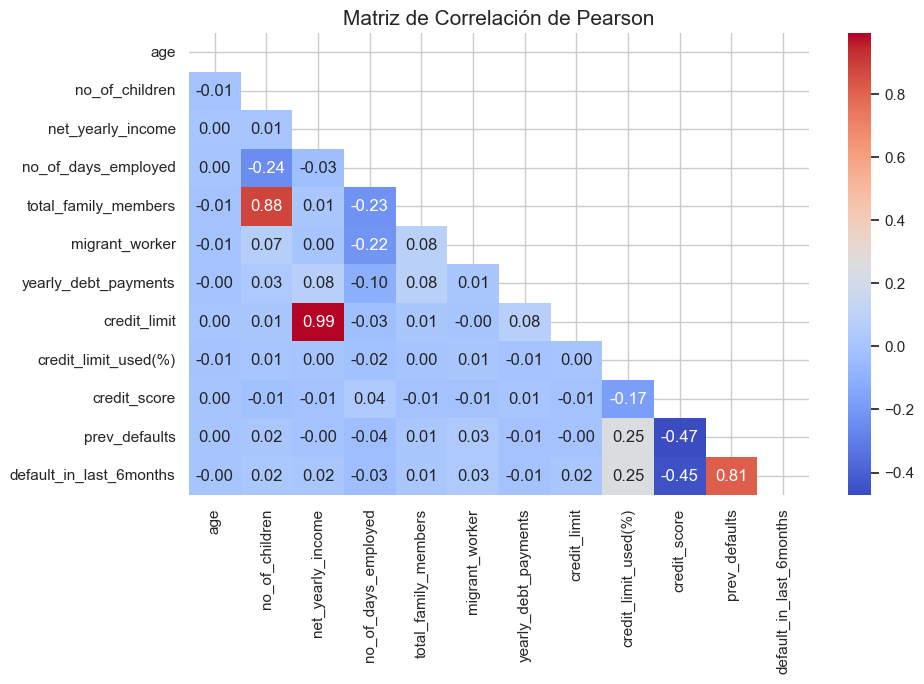

=== Reporte del análisis de correlación de Pearson ===
Se observa que existe una alta correlación entre las siguientes features:
- credit_limit vs net_yearly_income -> considerar eliminar alguna de las dos en modelamiento
- total_family_members vs no_of_children -> considerar eliminar alguna de las dos en modelamiento


In [ ]:
fig, ax = plt.subplots(1, 1, figsize= (10, 6))
corr = df_train[NUMERIC+[TARGET]].corr(method = 'pearson')
mask = np.triu(np.ones_like(corr, dtype= bool))
sns.heatmap(
    corr,
    mask = mask,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f',
    #center = 0
)
ax.set_title('Matriz de Correlación de Pearson', fontsize = 15)
plt.show()

print(f'=== Reporte del análisis de correlación de Pearson ===')
print(f'''Se observa que existe una alta correlación entre las siguientes features:
- credit_limit vs net_yearly_income (0.99) -> considerar eliminar alguna de las dos en modelamiento
- total_family_members vs no_of_children (0.88) -> considerar eliminar alguna de las dos en modelamiento''')


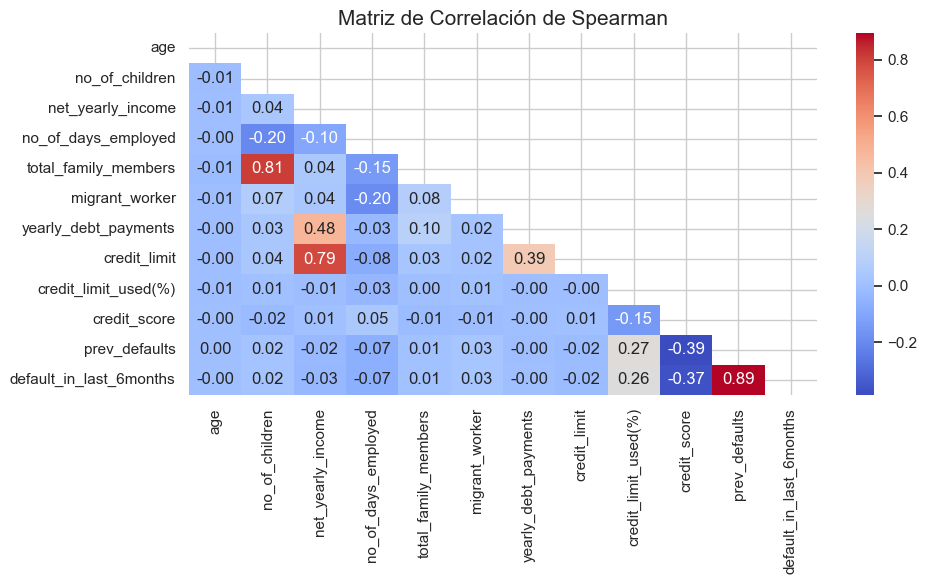

=== Reporte de Correlación de Spearman ===
Existe una alta monotonicidad entre:
- prev_defaults vs target
- credit_limit vs net_yearly_income
- no_of_childre vs total_family members


In [25]:
corr = df_train[NUMERIC + [TARGET]].corr(method = 'spearman')
mask = np.triu(np.ones_like(corr, dtype= bool))
fig, ax = plt.subplots(1, 1, figsize =(10, 6))
sns.heatmap(
    corr,
    mask= mask,
    fmt = '.2f',
    annot= True,
    cmap = 'coolwarm'
)
ax.set_title('Matriz de Correlación de Spearman', fontsize = 15)
plt.tight_layout()
plt.show()

print(f'=== Reporte de Correlación de Spearman ===')
print(f'''Existe una alta monotonicidad entre:
- prev_defaults vs target
- credit_limit vs net_yearly_income
- no_of_childre vs total_family members''')

#### Train / Test / Monitor split sizes

In [ ]:
class Drift:
    def __init__(self):
        pass

    def _pre_bins(self, bins: list):
        """Pre procesa los bins numéricos incluyendo los rangos -np.inf y np.inf"""
        bins[-1] = np.inf
        bins.insert(0, -np.inf)
        return bins

    
    def woe(self, features_numericas: list, features_categoricas: list, dataset: pd.DataFrame, target: pd.Series):
        """Retorna una lista de Dataframes para analizar la monotonicidad de cada feature"""
        lista_df_numericos = []
        lista_df_categoricas = []
        dataset_merge = dataset.copy()
        dataset_merge["target"] = target
        epsilon = 1e-6
        list_labels_num = []
        list_cortes_num = []
        list_intervalos_cat = []
        
        for i in features_numericas:
            cortes = pd.qcut(dataset_merge[i], q= 5, retbins=True, duplicates= "drop")[1].tolist()
            #intervalos = pd.qcut(dataset_merge[i], q= 5).cat.codes
            dataset_merge["bin"] = pd.qcut(dataset_merge[i], q= 5, duplicates= "drop")
            
            agg = dataset_merge.groupby(
                ["bin"], observed= False
            ).agg(
                total = ("target", "count"),
                eventos = ("target", "sum")
            )
            agg["no_eventos"] = agg["total"] - agg["eventos"]
            agg["event_rate"] = agg["eventos"] / agg["total"]
            agg["pct_obs"] = agg["total"] / agg["total"].sum()
            agg["dist_eventos"] = agg["eventos"] / agg["eventos"].sum()
            agg["dist_no_eventos"] = agg["no_eventos"] / agg["no_eventos"].sum()
            agg["woe"] = np.log(
                (agg["dist_no_eventos"] + epsilon)/(agg["dist_eventos"] + epsilon)
            )
            agg["iv"] = (agg["dist_no_eventos"] - agg["dist_eventos"]) * agg["woe"]

            agg = agg.reset_index()

            feature_num = pd.DataFrame({
                "feature": i,
                "bin": range(len(agg)),
                "intervalo": agg["bin"].astype("str"),
                "regla": cortes[1:],
                "n_observaciones": agg["total"],
                "pct_obs": agg["pct_obs"],
                "n_eventos": agg["eventos"],
                "n_no_eventos": agg["no_eventos"],
                "bad_rate": agg["event_rate"],
                "dist_eventos": agg["dist_eventos"],
                "dist_no_eventos": agg["dist_no_eventos"],
                "WOE":  agg["woe"],
                "IV": agg["iv"]
            })
            
            new_bins = self._pre_bins(bins = cortes[1:])
            lista_df_numericos.append(feature_num)
            list_labels_num.append(agg["bin"].astype("str"))
            list_cortes_num.append(new_bins)

        for i in features_categoricas:

            agg = dataset_merge.groupby(
                [i]
            ).agg(
                total = ("target", "count"),
                eventos = ("target", "sum")
            )

            agg["no_eventos"] = agg["total"] - agg["eventos"]
            agg["event_rate"] = agg["eventos"] / agg["total"]
            agg["dist_eventos"] = agg["eventos"] / agg["eventos"].sum()
            agg["dist_no_eventos"] = agg["no_eventos"] / agg["no_eventos"].sum()
            agg["woe"] = np.log(
                (agg["dist_no_eventos"] + epsilon)/(agg["dist_eventos"] + epsilon)
            )
            agg["iv"] = (agg["dist_no_eventos"] - agg["dist_eventos"]) * agg["woe"]
            agg["pct_obs"] = agg["total"] / agg["total"].sum()

            agg = agg.reset_index()

            feature_cat = pd.DataFrame({
                "feature": i,
                "bin": range(len(agg)),
                "intervalo": agg[i].astype("str"),
                "n_observaciones": agg["total"],
                "pct_obs": agg["pct_obs"],
                "n_eventos": agg["eventos"],
                "n_no_eventos": agg["no_eventos"],
                "bad_rate": agg["event_rate"],
                "dist_eventos": agg["dist_eventos"],
                "dist_no_eventos": agg["dist_no_eventos"],
                "WOE":  agg["woe"],
                "IV": agg["iv"]
            })
            lista_df_categoricas.append(feature_cat)
            list_intervalos_cat.append(agg[i].astype("str"))

        print("Lista de Dataframes creados exitosamente...")
        return lista_df_numericos, lista_df_categoricas, list_labels_num, list_cortes_num, list_intervalos_cat
    

    def woe_comparacion(self, features_numericas: list, features_categoricas: list, dataset: pd.DataFrame, target: pd.Series, labels_num = [], bins_num = [], intervalos_cat = []):
        """Retorna una lista de Dataframes para analizar la monotonicidad de cada feature"""
        lista_df_numericos = []
        lista_df_categoricas = []
        dataset_merge = dataset.copy()
        dataset_merge["target"] = target
        epsilon = 1e-6
        
        for x, i in enumerate(features_numericas):
            cortes = bins_num[x]
            #cortes = cortes[1:]
            #print(cortes)
            #print(type(cortes))
            dataset_merge["bin"] = pd.cut(
                dataset_merge[i],
                labels= labels_num[x],
                bins= bins_num[x]
            )
            #print(f"Tamaño dataset: {len(dataset_merge)}")
        
            agg = dataset_merge.groupby(
                ["bin"], observed= False
            ).agg(
                total = ("target", "count"),
                eventos = ("target", "sum")
            )
            #print(f"Tamaño agg: {len(agg)}")
            agg["no_eventos"] = agg["total"] - agg["eventos"]
            agg["event_rate"] = agg["eventos"] / agg["total"]
            agg["pct_obs"] = agg["total"] / agg["total"].sum()
            agg["dist_eventos"] = agg["eventos"] / agg["eventos"].sum()
            agg["dist_no_eventos"] = agg["no_eventos"] / agg["no_eventos"].sum()
            agg["woe"] = np.log(
                (agg["dist_no_eventos"] + epsilon)/(agg["dist_eventos"] + epsilon)
            )
            agg["iv"] = (agg["dist_no_eventos"] - agg["dist_eventos"]) * agg["woe"]

            agg = agg.reset_index()
            #print(len(agg))

            feature_num = pd.DataFrame({
                "feature": i,
                "bin": range(len(agg)),
                "intervalo": agg["bin"].astype("str"),
                "regla": cortes[1:],
                "n_observaciones": agg["total"],
                "pct_obs": agg["pct_obs"],
                "n_eventos": agg["eventos"],
                "n_no_eventos": agg["no_eventos"],
                "bad_rate": agg["event_rate"],
                "dist_eventos": agg["dist_eventos"],
                "dist_no_eventos": agg["dist_no_eventos"],
                "WOE":  agg["woe"],
                "IV": agg["iv"]
            })
            
            lista_df_numericos.append(feature_num)

        for x, i in enumerate(features_categoricas):
            cats = intervalos_cat[x]
            dataset_merge[i] = dataset_merge[i].where(
                dataset_merge[i].isin(cats),
                "OTHER"
            )

            agg = dataset_merge.groupby(
                [i]
            ).agg(
                total = ("target", "count"),
                eventos = ("target", "sum")
            )
            #print(agg)
            agg = agg.reindex(list(cats) + ["OTHER"], fill_value= 0)
            #print(f'========== DESPUÉS =========')
            #print(agg)
            
            agg["no_eventos"] = agg["total"] - agg["eventos"]
            agg["event_rate"] = agg["eventos"] / agg["total"]
            agg["dist_eventos"] = agg["eventos"] / agg["eventos"].sum()
            agg["dist_no_eventos"] = agg["no_eventos"] / agg["no_eventos"].sum()
            agg["woe"] = np.log(
                (agg["dist_no_eventos"] + epsilon)/(agg["dist_eventos"] + epsilon)
            )
            agg["iv"] = (agg["dist_no_eventos"] - agg["dist_eventos"]) * agg["woe"]
            agg["pct_obs"] = agg["total"] / agg["total"].sum()

            agg = agg.reset_index()

            feature_cat = pd.DataFrame({
                "feature": i,
                "bin": range(len(agg)),
                "intervalo": agg[i].astype("str"),
                "n_observaciones": agg["total"],
                "pct_obs": agg["pct_obs"],
                "n_eventos": agg["eventos"],
                "n_no_eventos": agg["no_eventos"],
                "bad_rate": agg["event_rate"],
                "dist_eventos": agg["dist_eventos"],
                "dist_no_eventos": agg["dist_no_eventos"],
                "WOE":  agg["woe"],
                "IV": agg["iv"]
            })
            lista_df_categoricas.append(feature_cat)

        print("Lista de Dataframes creados exitosamente...")
        return lista_df_numericos, lista_df_categoricas
    
    
    def psi(self, features_numericas: list, features_categoricas: list, dataset_base: pd.DataFrame, target: pd.Series, dataset_compare: pd.DataFrame, target_compare = pd.Series):
        """Calcula directamente el PSI, para ello calcula el WOE y PSI previamente"""
        list_feats_numericas_base, list_feats_categoricas_base, labels_num, bins_num, interv_cat = self.woe(
            dataset= dataset_base,
            features_categoricas= features_categoricas,
            features_numericas= features_numericas,
            target= target
        )
        #display(interv_cat)

        list_feats_num_comp, list_feats_cat_comp = self.woe_comparacion(
            features_numericas = features_numericas, 
            features_categoricas = features_categoricas,
            dataset = dataset_compare,
            target = target_compare,
            labels_num = labels_num,
            bins_num = bins_num, 
            intervalos_cat = interv_cat)
        
        #print(list_feats_cat_comp[0]['intervalo'])
        
        eps = 1e-6

        list_num_psi = []
        list_feat_num = []
        list_psi_num = []
        list_iv_base_num = []
        list_iv_comp_num = []

        print("Iniciando el cruce entre baseline y comparación para numéricas...")
        for base, comp in zip(list_feats_numericas_base, list_feats_num_comp):
            df_tmp = comp.merge(base, how = "left", on = ["feature" , "bin"], suffixes = ("", "_base"))
            feat_num = ["feature", "bin", "regla", "pct_obs", "pct_obs_base", "WOE", "WOE_base", "IV", "IV_base"]
            df_tmp = df_tmp[feat_num]
            df_tmp["psi"] = ( df_tmp["pct_obs_base"].clip(eps, 1) - df_tmp["pct_obs"].clip(eps, 1) ) * np.log( (df_tmp["pct_obs_base"].clip(eps, 1)) / (df_tmp["pct_obs"].clip(eps, 1))  )
            
            feature = df_tmp["feature"].unique()[0]
            psi = df_tmp["psi"].sum()
            iv_base = df_tmp["IV_base"].sum()
            iv_comp = df_tmp["IV"].sum()

            list_num_psi.append(df_tmp)

            list_feat_num.append(feature)
            list_psi_num.append(psi)
            list_iv_base_num.append(iv_base)
            list_iv_comp_num.append(iv_comp)

        print("Iniciando el cruce entre baseline y comparación para categóricas...")
        for base, comp in zip(list_feats_categoricas_base, list_feats_cat_comp):
            df_tmp = comp.merge(base, how = "left", on = ["feature" , "intervalo"], suffixes = ("", "_base"))
            feat_num = ["feature", "bin", "bin_base", "intervalo", "pct_obs", "pct_obs_base", "WOE", "WOE_base", "IV", "IV_base"]
            df_tmp = df_tmp[feat_num]
            df_tmp["psi"] = ( df_tmp["pct_obs_base"].clip(eps, 1) - df_tmp["pct_obs"].clip(eps, 1) ) * np.log( (df_tmp["pct_obs_base"].clip(eps, 1)) / (df_tmp["pct_obs"].clip(eps, 1))  )
            
            feature = df_tmp["feature"].unique()[0]
            psi = df_tmp["psi"].sum()
            iv_base = df_tmp["IV_base"].sum()
            iv_comp = df_tmp["IV"].sum()

            list_num_psi.append(df_tmp)

            list_feat_num.append(feature)
            list_psi_num.append(psi)
            list_iv_base_num.append(iv_base)
            list_iv_comp_num.append(iv_comp)

        print("Creando el resumen...")

        df_overall = pd.DataFrame({
            "Feature": list_feat_num,
            "PSI": list_psi_num,
            "IV Base": list_iv_base_num,
            "IV Comparative": list_iv_comp_num
        }).sort_values(by= "PSI", ascending= False)

        return df_overall, list_num_psi
        


In [86]:
drift = Drift()
df_overall, list_num_psi = drift.psi(
features_numericas = NUMERIC,
features_categoricas = CATEGORICAL,
dataset_base = df_train,
target = df_train[TARGET],
dataset_compare = df_test,
target_compare = df_test[TARGET])

Lista de Dataframes creados exitosamente...
Lista de Dataframes creados exitosamente...
Iniciando el cruce entre baseline y comparación para numéricas...
Iniciando el cruce entre baseline y comparación para categóricas...
Creando el resumen...


In [ ]:
display(df_overall)
print(f'=== Reporte del análisis de PSI ===')
print(f'No se observa drift en ninguna de las features (Train vs Test)')
print(f'Se ha identificado dos variables altamente predictivas como son: credit_limit_used(%) y credit_score')      

,Feature,PSI,IV Base,IV Comparative
14,occupation_type,0.002426,0.078599,0.065656
3,no_of_days_employed,0.000803,0.097046,0.075490
7,credit_limit,0.000450,0.010150,0.006424
8,credit_limit_used(%),0.000331,8.526133,8.597281
2,net_yearly_income,0.000304,0.026601,0.012028
12,owns_car,0.000295,0.005713,0.004883
0,age,0.000278,0.000449,0.007122
6,yearly_debt_payments,0.000276,0.018535,0.032195
9,credit_score,0.000265,11.866081,11.877216
11,gender,0.000165,0.041878,0.048385


=== Reporte del análisis de PSI ===
No se observa drift en ninguna de las features (Train vs Test)
Se ha identificado dos variables altamente predictivas como son: credit_limit_used(%) y credit_score


In [88]:
for i in list_num_psi:
    display(i)

,feature,bin,regla,pct_obs,pct_obs_base,WOE,WOE_base,IV,IV_base,psi
0,age,0,29.0,0.213915,0.213275,0.136843,-0.011218,0.003767,0.000027,1.918490e-06
1,age,1,36.0,0.207766,0.212199,-0.111957,-0.020793,0.002740,0.000093,9.359483e-05
2,age,2,42.0,0.178951,0.181207,-0.050380,0.025442,0.000465,0.000116,2.826570e-05
3,age,3,49.0,0.216551,0.210815,0.026327,-0.014911,0.000148,0.000047,1.539660e-04
4,age,4,inf,0.182816,0.182503,0.002913,0.030356,0.000002,0.000166,5.377382e-07


,feature,bin,regla,pct_obs,pct_obs_base,WOE,WOE_base,IV,IV_base,psi
0,no_of_children,0,1.0,0.899937,0.898825,0.000353,0.022048,1.123807e-07,0.000433,0.000001
1,no_of_children,1,inf,0.100063,0.101175,-0.003173,-0.178864,1.009108e-06,0.003510,0.000012


,feature,bin,regla,pct_obs,pct_obs_base,WOE,WOE_base,IV,IV_base,psi
0,net_yearly_income,0,115740.638,0.196521,0.200009,0.068430,-0.070456,0.000892,0.001025,0.000061
1,net_yearly_income,1,152986.014,0.200650,0.199987,-0.098050,-0.125091,0.002017,0.003311,0.000002
2,net_yearly_income,2,196416.690,0.202231,0.200009,-0.106937,-0.120874,0.002427,0.003086,0.000025
3,net_yearly_income,3,258960.448,0.195643,0.199987,-0.025066,0.049541,0.000124,0.000480,0.000095
4,net_yearly_income,4,inf,0.204955,0.200009,0.186642,0.328858,0.006567,0.018699,0.000121


,feature,bin,regla,pct_obs,pct_obs_base,WOE,WOE_base,IV,IV_base,psi
0,no_of_days_employed,0,747.0,0.200213,0.200133,-0.315375,-0.351093,0.022996,0.028939,3.170329e-08
1,no_of_days_employed,1,1605.0,0.200479,0.199889,-0.269733,-0.221603,0.016494,0.010853,1.737483e-06
2,no_of_days_employed,2,3074.4,0.209700,0.199978,0.179335,-0.031532,0.006224,0.000202,4.615555e-04
3,no_of_days_employed,3,9238.0,0.197375,0.200044,0.342974,0.396867,0.019937,0.026445,3.584849e-05
4,no_of_days_employed,4,inf,0.192233,0.199956,0.238619,0.430132,0.009839,0.030608,3.041995e-04


,feature,bin,regla,pct_obs,pct_obs_base,WOE,WOE_base,IV,IV_base,psi
0,total_family_members,0,2.0,0.733615,0.73425,0.024647,0.059828,0.000441,0.002559,5.493523e-07
1,total_family_members,1,3.0,0.172745,0.17190,-0.087624,-0.144786,0.001380,0.003847,4.141505e-06
2,total_family_members,2,inf,0.093640,0.09385,-0.022538,-0.160482,0.000048,0.002599,4.696255e-07


...

,feature,bin,regla,pct_obs,pct_obs_base,WOE,WOE_base,IV,IV_base,psi
0,prev_defaults,0,inf,1.0,1.0,0.0,0.0,0.0,0.0,0.0


,feature,bin,bin_base,intervalo,pct_obs,pct_obs_base,WOE,WOE_base,IV,IV_base,psi
0,gender,0,0.0,F,0.653870,0.657991,0.176644,0.162327,0.018851,0.016126,0.000026
1,gender,1,1.0,M,0.346042,0.341987,-0.272594,-0.258423,0.029116,0.025679,0.000048
2,gender,2,2.0,XNA,0.000088,0.000022,4.536298,3.183609,0.000419,0.000074,0.000091
3,gender,3,NaN,OTHER,0.000000,NaN,0.000000,NaN,0.000000,NaN,NaN


,feature,bin,bin_base,intervalo,pct_obs,pct_obs_base,WOE,WOE_base,IV,IV_base,psi
0,owns_car,0,0.0,N,0.647632,0.661235,-0.040874,-0.052186,0.001102,0.001844,0.000283
1,owns_car,1,1.0,Y,0.340771,0.338765,0.067660,0.109519,0.001513,0.003869,0.000012
2,owns_car,2,NaN,OTHER,0.011596,NaN,0.492864,NaN,0.002267,NaN,NaN


,feature,bin,bin_base,intervalo,pct_obs,pct_obs_base,WOE,WOE_base,IV,IV_base,psi
0,owns_house,0,0.0,N,0.309409,0.304999,0.014894,-0.015199,0.000068,0.000071,0.000063
1,owns_house,1,1.0,Y,0.690591,0.695001,-0.006608,0.006736,0.000030,0.000031,0.000028
2,owns_house,2,NaN,OTHER,0.000000,NaN,0.000000,NaN,0.000000,NaN,NaN


,feature,bin,bin_base,intervalo,pct_obs,pct_obs_base,WOE,WOE_base,IV,IV_base,psi
0,occupation_type,0,0.0,Accountants,0.032065,0.032376,0.498564,0.524925,0.006399,0.007087,2.988760e-06
1,occupation_type,1,1.0,Cleaning staff,0.014407,0.014606,0.297993,-0.261366,0.001120,0.001123,2.728371e-06
2,occupation_type,2,2.0,Cooking staff,0.018273,0.019812,-0.087505,-0.426378,0.000146,0.004374,1.244686e-04
3,occupation_type,3,3.0,Core staff,0.089432,0.089220,0.333250,0.349012,0.008565,0.009313,5.021407e-07
4,occupation_type,4,4.0,Drivers,0.061759,0.060336,-0.110616,-0.333551,0.000795,0.007812,3.313699e-05
5,occupation_type,5,5.0,HR staff,0.002723,0.001713,0.428186,-0.251968,0.000413,0.000122,4.681790e-04
6,occupation_type,6,6.0,High skill tech staff,0.035579,0.036944,0.095232,0.329915,0.000309,0.003475,5.138298e-05
7,occupation_type,7,7.0,IT staff,0.002460,0.001450,-0.407730,1.239632,0.000493,0.001325,5.341238e-04
8,occupation_type,8,8.0,Laborers,0.181938,0.178659,-0.236082,-0.287590,0.011291,0.016837,5.962392e-05
9,occupation_type,9,9.0,Low-skill Laborers,0.005359,0.007380,-1.081833,-0.646729,0.010327,0.004150,6.468479e-04


In [90]:
print('=== Reporte del Análisis con WOE/PSI ===')
print(f'''Candidatas para WOE:
- no_of_days_employed
- credit_limit_used(%)
- credit_score (reducir bins)''')

print(f'''Candidatas a Log-Transformation:
- credit_limit
- total_family_members
- yearly_debt_payments''')


print(f'''Inspeccionar con nuevos bins: (Si queda tiempo)
- net_yearly_income
- yearly_debt_payments''')

=== Reporte del Análisis con WOE/PSI ===
Candidatas para WOE:
- no_of_days_employed
- credit_limit_used(%)
- credit_score (reducir bins)
Candidatas a Log-Transformation:
- credit_limit
- total_family_members
- yearly_debt_payments
Inspeccionar con nuevos bins: (Si queda tiempo)
- net_yearly_income
- yearly_debt_payments


### Calcular VIF

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def vif(dataset: pd.DataFrame, feats_numericas: list):
    dataset_vf = dataset.copy()
    dataset_vf_dropna = dataset_vf.dropna()
    list_r2 = []
    list_vif = []
    for feat in feats_numericas:
        X_train = dataset_vf_dropna[ [col for col in feats_numericas if col != feat] ]
        y_train = dataset_vf_dropna[feat]
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        r2 = r2_score(y_train, y_pred_train)
        list_r2.append(round(r2, 5))
        vif = 1/(1-r2)
        list_vif.append(round(vif, 4))
    
    return pd.DataFrame({
        'Feature': feats_numericas,
        'R2': list_r2,
        'VIF': list_vif
    }).sort_values(by = 'VIF', ascending = False)

display(vif(dataset = df_train, feats_numericas = NUMERIC))
print('=== Reporte de Análisis VIF ===')
print(f'''Se observa dos features con alto VIF, altamente correlacionados por lo que existe multicolinealidad.
Alguna de las dos será candidata a eliminar:
- net_yearly_income
- credit_limit''')


,Feature,R2,VIF
2,net_yearly_income,0.98729,78.6596
7,credit_limit,0.98728,78.6337
1,no_of_children,0.77913,4.5276
4,total_family_members,0.77860,4.5167
10,prev_defaults,0.25417,1.3408
9,credit_score,0.22642,1.2927
3,no_of_days_employed,0.11156,1.1256
8,credit_limit_used(%),0.06777,1.0727
5,migrant_worker,0.05067,1.0534
6,yearly_debt_payments,0.02883,1.0297


=== Reporte de Análisis VIF ===
Se observa dos features con alto VIF, altamente correlacionados por lo que existe multicolinealidad.
Alguna de las dos será candidata a eliminar:
- net_yearly_income
- credit_limit


### Resumen del EDA

In [104]:
eda_output = '''=== Features Numéricas con Missings ===
- no_of_children (1.7%)
- no_of_days_employed (1.02%)
- yearly_debt_payments (0.21%)
- migrant_worker (0.19%)
- total_family_members (0.18%)
- credit_score (0.02%)

=== Features Categóricas con Missings ===
- owns_car (1.2%)
      
=== Reporte de Balanceamiento del Target ===
A nivel del dataset train tiene:
- 5% -> Default
- 95% -> No Default
Recomendación: Mirar Recall como kpi principal junto al AUC. Ponderar pesos entre default/nodefault

=== Reporte Feature vs Target ===
Se observa señal algunas señales fuertes que presuntamente indicarían poder predictivo relevante
Algunas de ellas son:
- prev_defaults
- credit_score
- credit_limit_used(%)
- credit_limit
- no_of_days_employed
- net_yearly_income
- gender

=== Reporte de Distribución de Features ===
Se observa que hay muchas features con sesgo hacia la derecha por naturaleza de la variable, 
por ello se recomienda aplicar una log-tranformation o el método WOE en al menos las siguientes:
- no_of_children
- net_yearly_income
- no_of_days_employed
- no_of_days_employed
- credit_limit
- yearly_debt_payments

=== Reporte del análisis de correlación de Pearson ===
Se observa que existe una alta correlación entre las siguientes features:
- credit_limit vs net_yearly_income (0.99) -> considerar eliminar alguna de las dos en modelamiento
- total_family_members vs no_of_children (0.88) -> considerar eliminar alguna de las dos en modelamiento

=== Reporte de Correlación de Spearman ===
Existe una alta monotonicidad entre:
- prev_defaults vs target (0.90)

=== Reporte de Análisis VIF ===
Se observa dos features con alto VIF, altamente correlacionados por lo que existe multicolinealidad.
Alguna de las dos será candidata a eliminar:
- net_yearly_income
- credit_limit

=== Reporte del análisis de PSI ===
No se observa drift en ninguna de las features (Train vs Test)
Se ha identificado dos variables altamente predictivas como son: 
- credit_limit_used(%)
- credit_score

=== Reporte del Análisis con WOE/PSI ===
Candidatas para WOE:
- no_of_days_employed
- credit_limit_used(%)
- credit_score (reducir bins)

Candidatas a Log-Transformation:
- credit_limit
- total_family_members
- yearly_debt_payments'''
print(eda_output)

with open('./eda_output.txt', 'w') as f:
      f.write(eda_output)

=== Features Numéricas con Missings ===
- no_of_children (1.7%)
- no_of_days_employed (1.02%)
- yearly_debt_payments (0.21%)
- migrant_worker (0.19%)
- total_family_members (0.18%)
- credit_score (0.02%)

=== Features Categóricas con Missings ===
- owns_car (1.2%)

=== Reporte de Balanceamiento del Target ===
A nivel del dataset train tiene:
- 5% -> Default
- 95% -> No Default
Recomendación: Mirar Recall como kpi principal junto al AUC. Ponderar pesos entre default/nodefault

=== Reporte Feature vs Target ===
Se observa señal algunas señales fuertes que presuntamente indicarían poder predictivo relevante
Algunas de ellas son:
- prev_defaults
- credit_score
- credit_limit_used(%)
- credit_limit
- no_of_days_employed
- net_yearly_income
- gender

=== Reporte de Distribución de Features ===
Se observa que hay muchas features con sesgo hacia la derecha por naturaleza de la variable, 
por ello se recomienda aplicar una log-tranformation o el método WOE en al menos las siguientes:
- no_of_ch

In [2]:
###